# Import libraries

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchgeo.transforms import AugmentationSequential
import kornia.augmentation as K
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from torchgeo.models import ResNet50_Weights
from torch.utils.data import DataLoader
from pugs_detection.raster import create_image_tiles
from pugs_detection.modeling.model import modify_first_layer
from pugs_detection.plots import (
    plot_image_tiles,
    visualize_from_torchgeo_dataloader,
    visualize_predictions,
)
from pugs_detection.modeling.segmentation_task import (
    CustomSegmentationTask
)
from pugs_detection.utils import set_all_seeds
from pugs_detection.dataset import create_dataset_split

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set seed to make it reproducible

In [3]:
# Set seeds for reproducibility
set_all_seeds(42)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


# Create image tiles for training, validation, and test set

Manually specify tile

In [ ]:
# train, validation, test index list
# train_index_list = [3, 4, 6, 7, 11, 12, 13, 15, 16, 18, 19, 20, 22, 23, 25]
# val_index_list = [2, 5, 9, 21, 24]
# test_index_list = [1, 8, 10, 14, 17]
train_index_list = [3, 11, 12, 13, 15, 16, 18]
val_index_list = [7, 17, 22]
test_index_list = [8, 14, 19]
output_folder_path = "../data/processed/tiles"
image_path = "../data/processed/sentinel-2/stacked_sentinel2_dresden_clipped.geotiff"

In [5]:
all_tiles_list = create_image_tiles(
    output_folder_path, image_path, train_index_list, val_index_list, test_index_list
)

Image bounds width: 27110.0 height: 22640.0
Tile dimensions width: 5422.0 height: 4528.0
Skipping tile 1: only 0.0% valid data
Skipping tile 2: only 44.4% valid data
Tile 3 saved to train folder (85.5% valid data)
Skipping tile 4: only 7.0% valid data
Skipping tile 5: only 0.0% valid data
Skipping tile 6: only 13.3% valid data
Tile 7 saved to val folder (93.8% valid data)
Tile 8 saved to test folder (95.8% valid data)
Skipping tile 9: only 36.9% valid data
Skipping tile 10: only 0.8% valid data
Tile 11 saved to train folder (59.9% valid data)
Tile 12 saved to train folder (100.0% valid data)
Tile 13 saved to train folder (100.0% valid data)
Tile 14 saved to test folder (98.8% valid data)
Tile 15 saved to train folder (54.1% valid data)
Tile 16 saved to train folder (77.8% valid data)
Tile 17 saved to val folder (100.0% valid data)
Tile 18 saved to train folder (99.7% valid data)
Tile 19 saved to train folder (92.3% valid data)
Skipping tile 20: only 35.7% valid data
Skipping tile 21: o

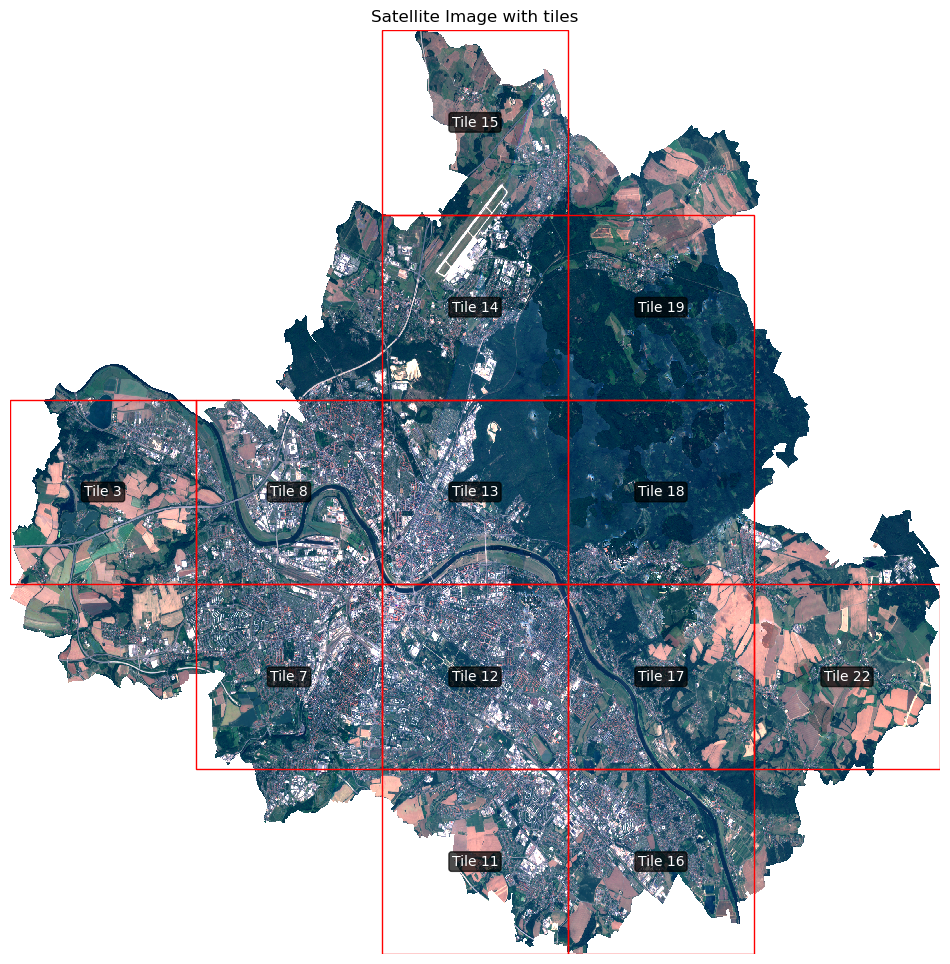

In [6]:
plot_image_tiles(image_path, all_tiles_list)

# Creating image patches

In [7]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

In [8]:
# Define paths for pre-split tiles
train_image_path = "../data/processed/tiles/train"
val_image_path = "../data/processed/tiles/val"
test_image_path = "../data/processed/tiles/test"

In [ ]:
# Vector data path
label_path = "../data/processed/ground truth/dresden_pugs_gt.geojson"

In [11]:
# Create specific augmentation transforms
h_flip_transform = AugmentationSequential(
    K.RandomHorizontalFlip(p=1.0), data_keys=["image", "mask"]
)

v_flip_transform = AugmentationSequential(
    K.RandomVerticalFlip(p=1.0), data_keys=["image", "mask"]
)

rotation_transform = AugmentationSequential(
    K.RandomRotation(degrees=45, p=1.0, align_corners=True), data_keys=["image", "mask"]
)

In [12]:
# Create list of specific transforms
transform_list = [h_flip_transform, v_flip_transform, rotation_transform]

In [ ]:
band_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

## Create training dataset

In [14]:
# Create the filtered datasets
train_dataset = create_dataset_split(
    train_image_path, label_path, 32633, band_list, "train", transform_list
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
Found 108 valid patches out of 108 total patches


In [15]:
print(len(train_dataset))

432


In [16]:
# Create DataLoaders
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=stack_samples,
    num_workers=3,
)

In [17]:
len(train_loader)

27

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Sample 0:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.03


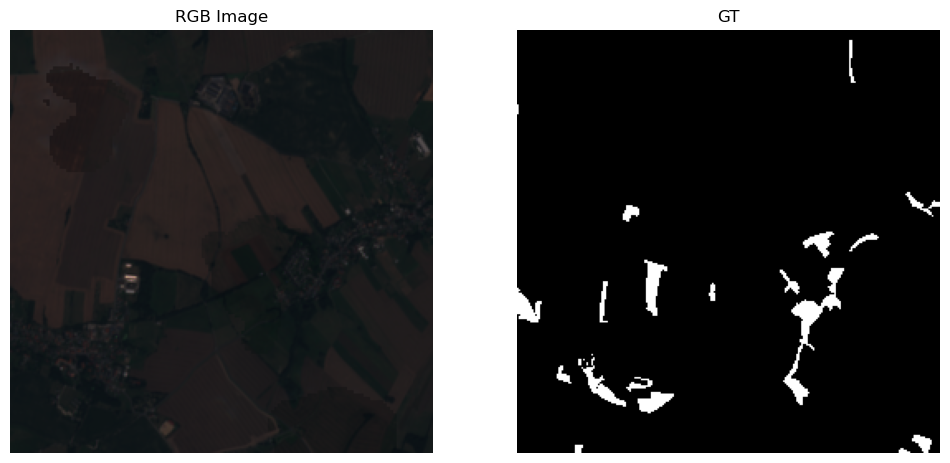

Sample 1:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.03


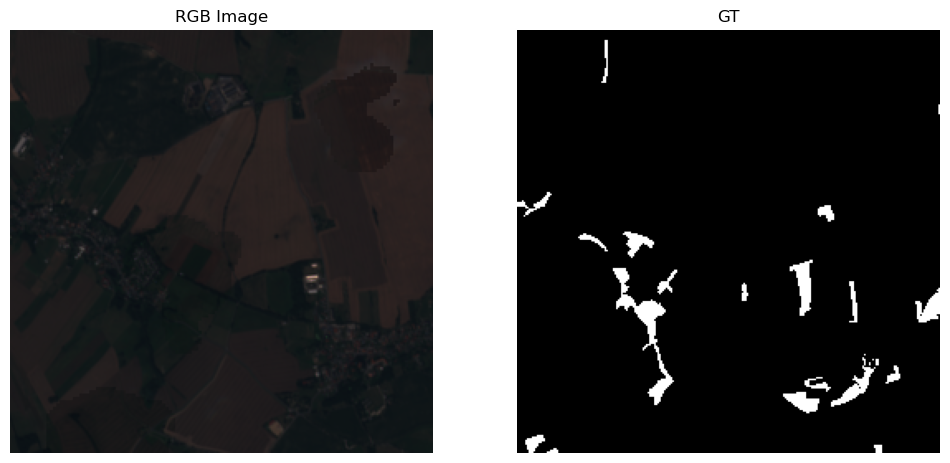

Sample 2:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.16


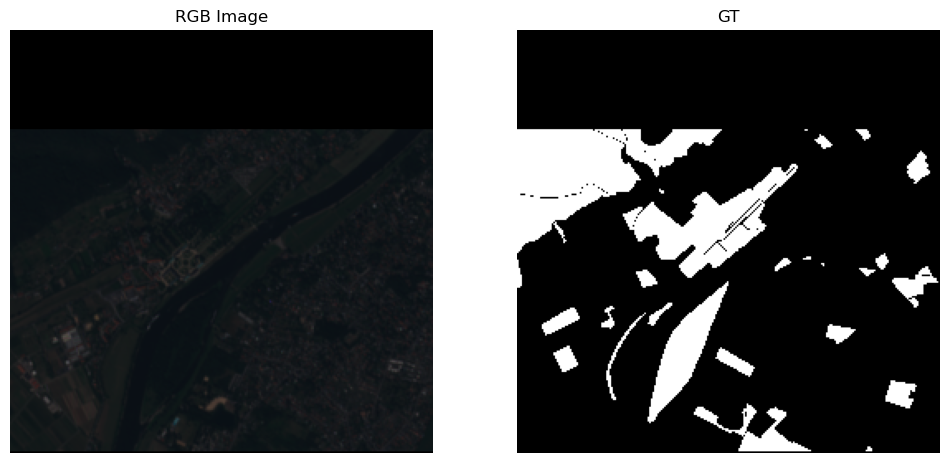

Sample 3:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.30


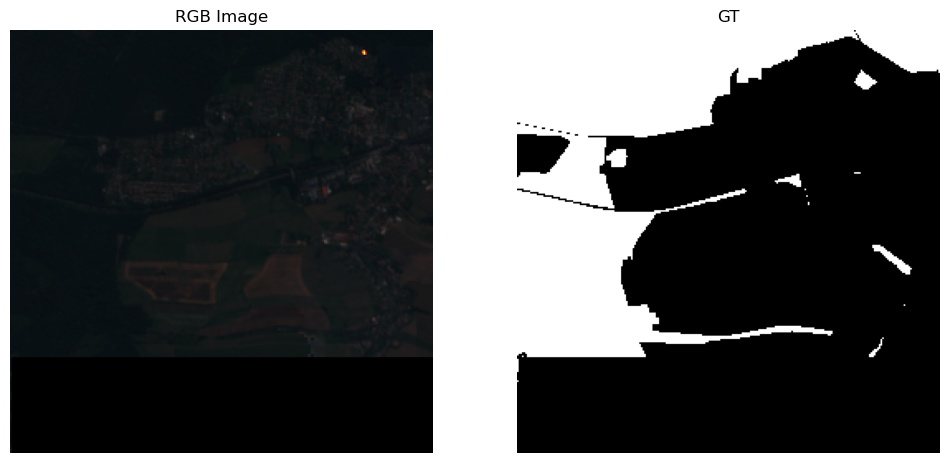

Sample 4:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.64


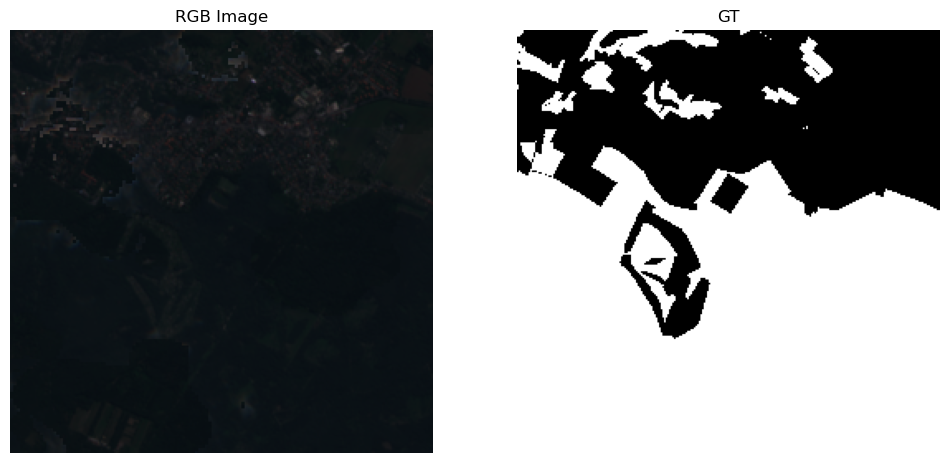

In [18]:
# visualize_from_torchgeo_dataloader(train_loader, 5, 'additional', [13])
visualize_from_torchgeo_dataloader(train_loader, 5, "original")

## Create validation dataset

Set transform_sequence to None by default or optional params

In [19]:
val_dataset = create_dataset_split(
    val_image_path, label_path, 32633, band_list, "validation", None
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Using all 24 patches for validation set


In [20]:
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=2
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Sample 0:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.11


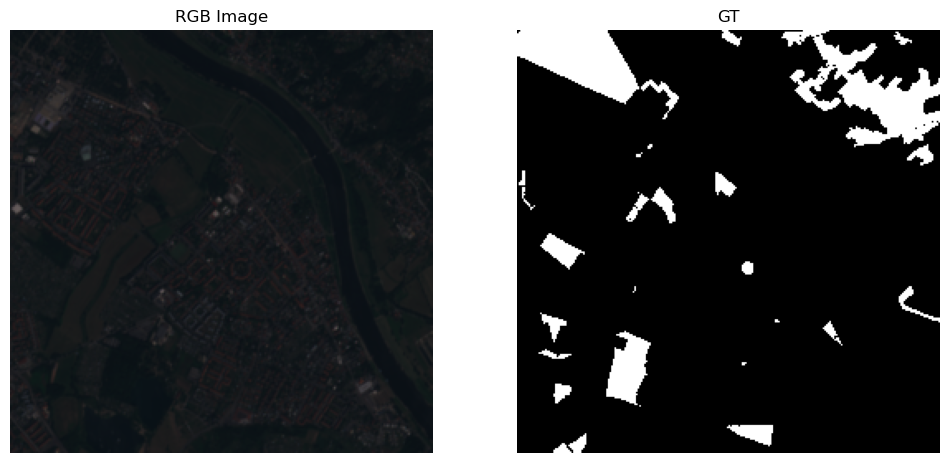

Sample 1:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.18


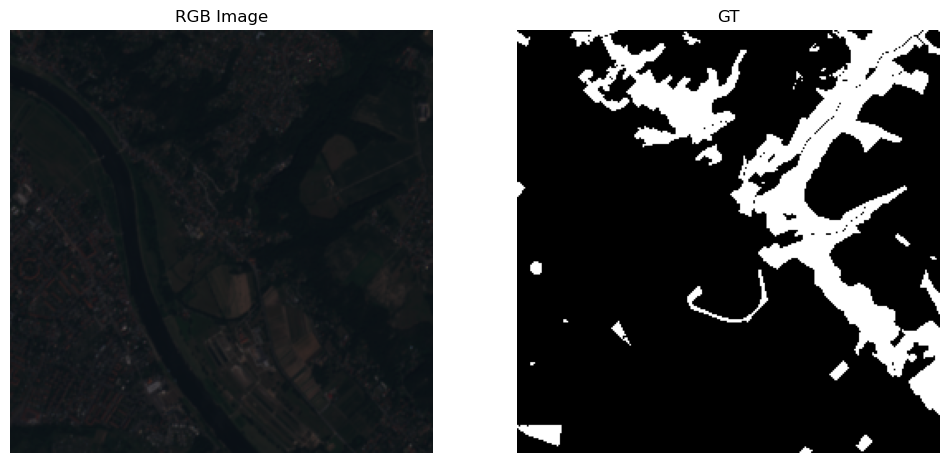

Sample 2:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.20


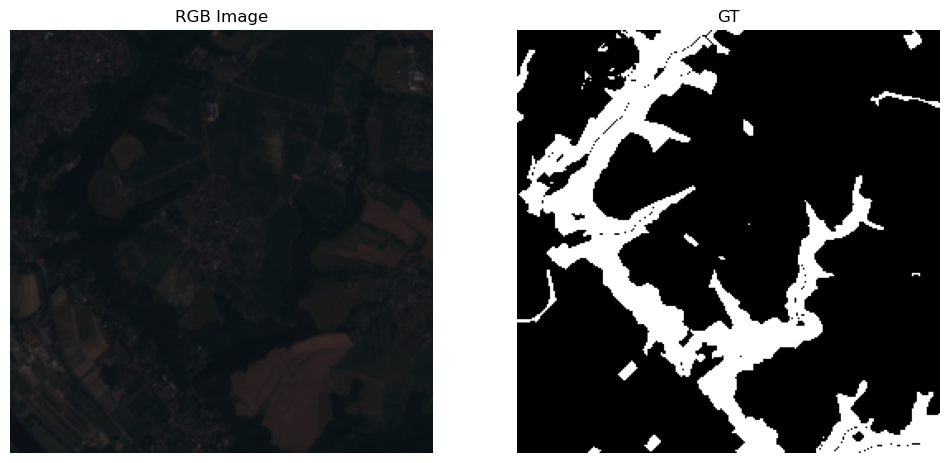

In [21]:
# visualize_from_torchgeo_dataloader(val_loader, 3, 'additional', [13])
visualize_from_torchgeo_dataloader(val_loader, 3, "original")

## Create test dataset

Set transform_sequence to None by default or optional params

In [22]:
test_dataset = create_dataset_split(
    test_image_path, label_path, 32633, band_list, "test", None
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Using all 24 patches for test set


In [23]:
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=1
)

In [24]:
len(test_loader)

2

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Sample 0:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


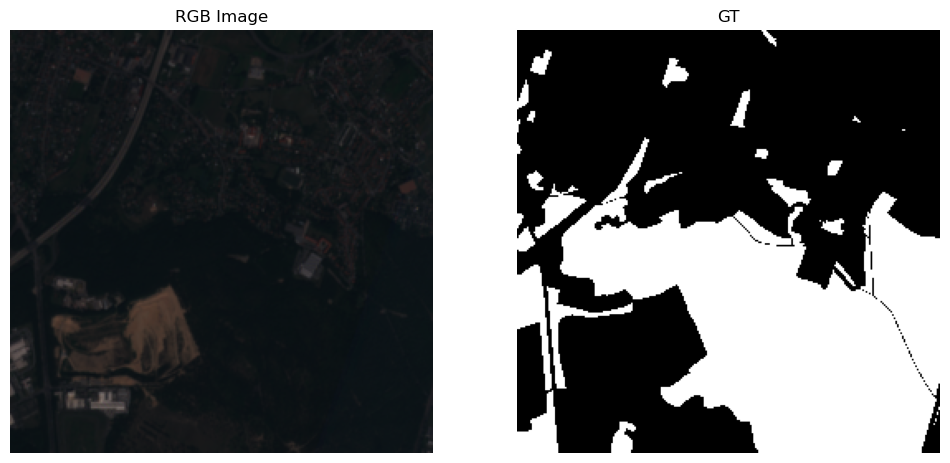

Sample 1:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


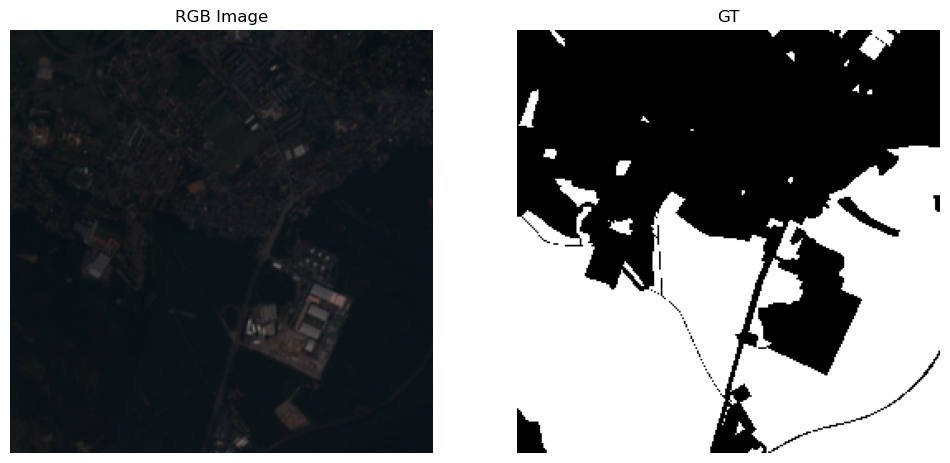

Sample 2:
  Image shape: (13, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


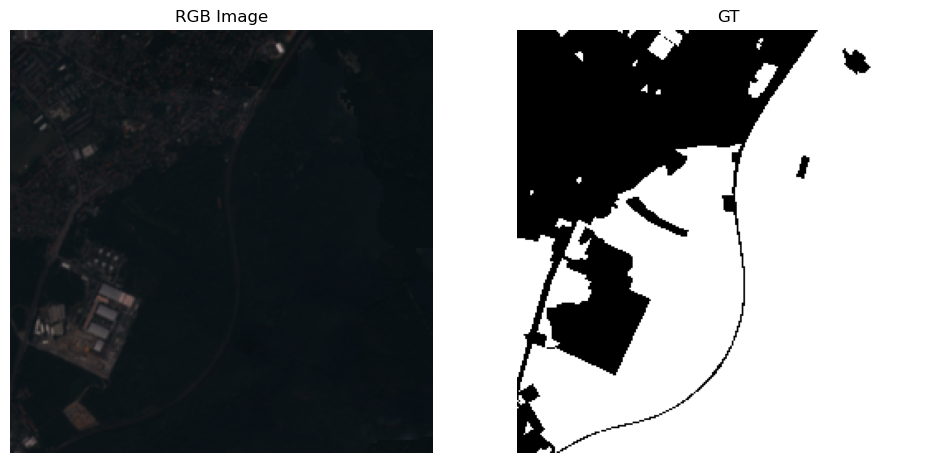

In [25]:
# visualize_from_torchgeo_dataloader(test_loader, 3, 'additional', [13])
visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# Create and train model

In [26]:
# batch_size = 10
# num_workers = 2
# max_epochs = 10
# fast_dev_run = False

In [27]:
weight_test = ResNet50_Weights.SENTINEL2_ALL_MOCO
# weight_test = ResNet50_Weights.SENTINEL2_MI_MS_SATLAS

## Modified model

13 channels + OSM binary mask

In [38]:
# Use the custom task
# task = SemanticSegmentationTask(
#     weights=weight_test,
#     loss='jaccard',
#     model='unet',
#     backbone="resnet50",
#     num_classes=2,
#     in_channels=13,
#     lr=0.01,
#     patience=5,
# )

# task = modify_first_layer(task, in_channels=14)


# task = SemanticSegmentationTask(
#     loss='focal',
#     model='unet',
#     backbone="resnet50",
#     weights=weight_test,
#     in_channels=13,
#     num_classes=2,
#     lr=0.0001,
#     patience=5,
# )

task = CustomSegmentationTask(
    loss="jaccard",
    model="unet",
    backbone="resnet50",
    weights=weight_test,
    in_channels=13,
    num_classes=1,
    lr=0.0001,
    patience=5,
)

task = modify_first_layer(task, in_channels=14)

CustomSegmentationTask(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(14, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (re

## Original model

In [29]:
# task = SemanticSegmentationTask(
#     loss='jaccard',
#     model='unet',
#     backbone="resnet50",
#     weights=weight_test,
#     in_channels=13,
#     num_classes=2,
#     lr=0.01,
#     patience=5,
# )

# task = SemanticSegmentationTask(
#     loss='jaccard',
#     model='unet',
#     backbone="resnet50",
#     weights=weight_test,
#     in_channels=13,
#     num_classes=2,
#     lr=0.001,
#     patience=5,
# )

task = CustomSegmentationTask(
    loss="jaccard",
    model="unet",
    backbone="resnet50",
    weights=weight_test,
    in_channels=13,
    num_classes=1,
    lr=0.0001,
    patience=5,
)

## Training

In [ ]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=3,  # Save chckpoint with the best validation loss
    # every_n_epochs=5  # Save checkpoint every n epochs
)

In [ ]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10)

In [ ]:
logger = CSVLogger("lightning_logs", name="pugs_detection")

In [33]:
trainer = Trainer(
    max_epochs=30,
    deterministic=True,
    accelerator="cpu",
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [35]:
trainer.fit(model=task, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Unet             | 32.6 M | train
1 | criterion     | JaccardLoss      | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
32.6 M    Trainable params
0         Non-trainable params
32.6 M    Total params
130.210   Total estimated model params size (MB)
233       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Unet             | 32.6 M | train
1 | criterion     | JaccardLoss      | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollec

Epoch 29: 100%|██████████| 27/27 [02:46<00:00,  0.16it/s, v_num=10]        

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 27/27 [02:46<00:00,  0.16it/s, v_num=10]


---

# This section should be in new notebook

In [ ]:
trainer.test(model=task, dataloaders=test_loader)

/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 2/2 [00:03<00:00,  0.54it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_BinaryAccuracy      0.9565207362174988
 test_BinaryJaccardIndex    0.7844931483268738
        test_loss           0.4057328999042511
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_BinaryAccuracy': 0.9565207362174988,
  'test_BinaryJaccardIndex': 0.7844931483268738,
  'test_loss': 0.4057328999042511}]

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 3 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7983424067497253


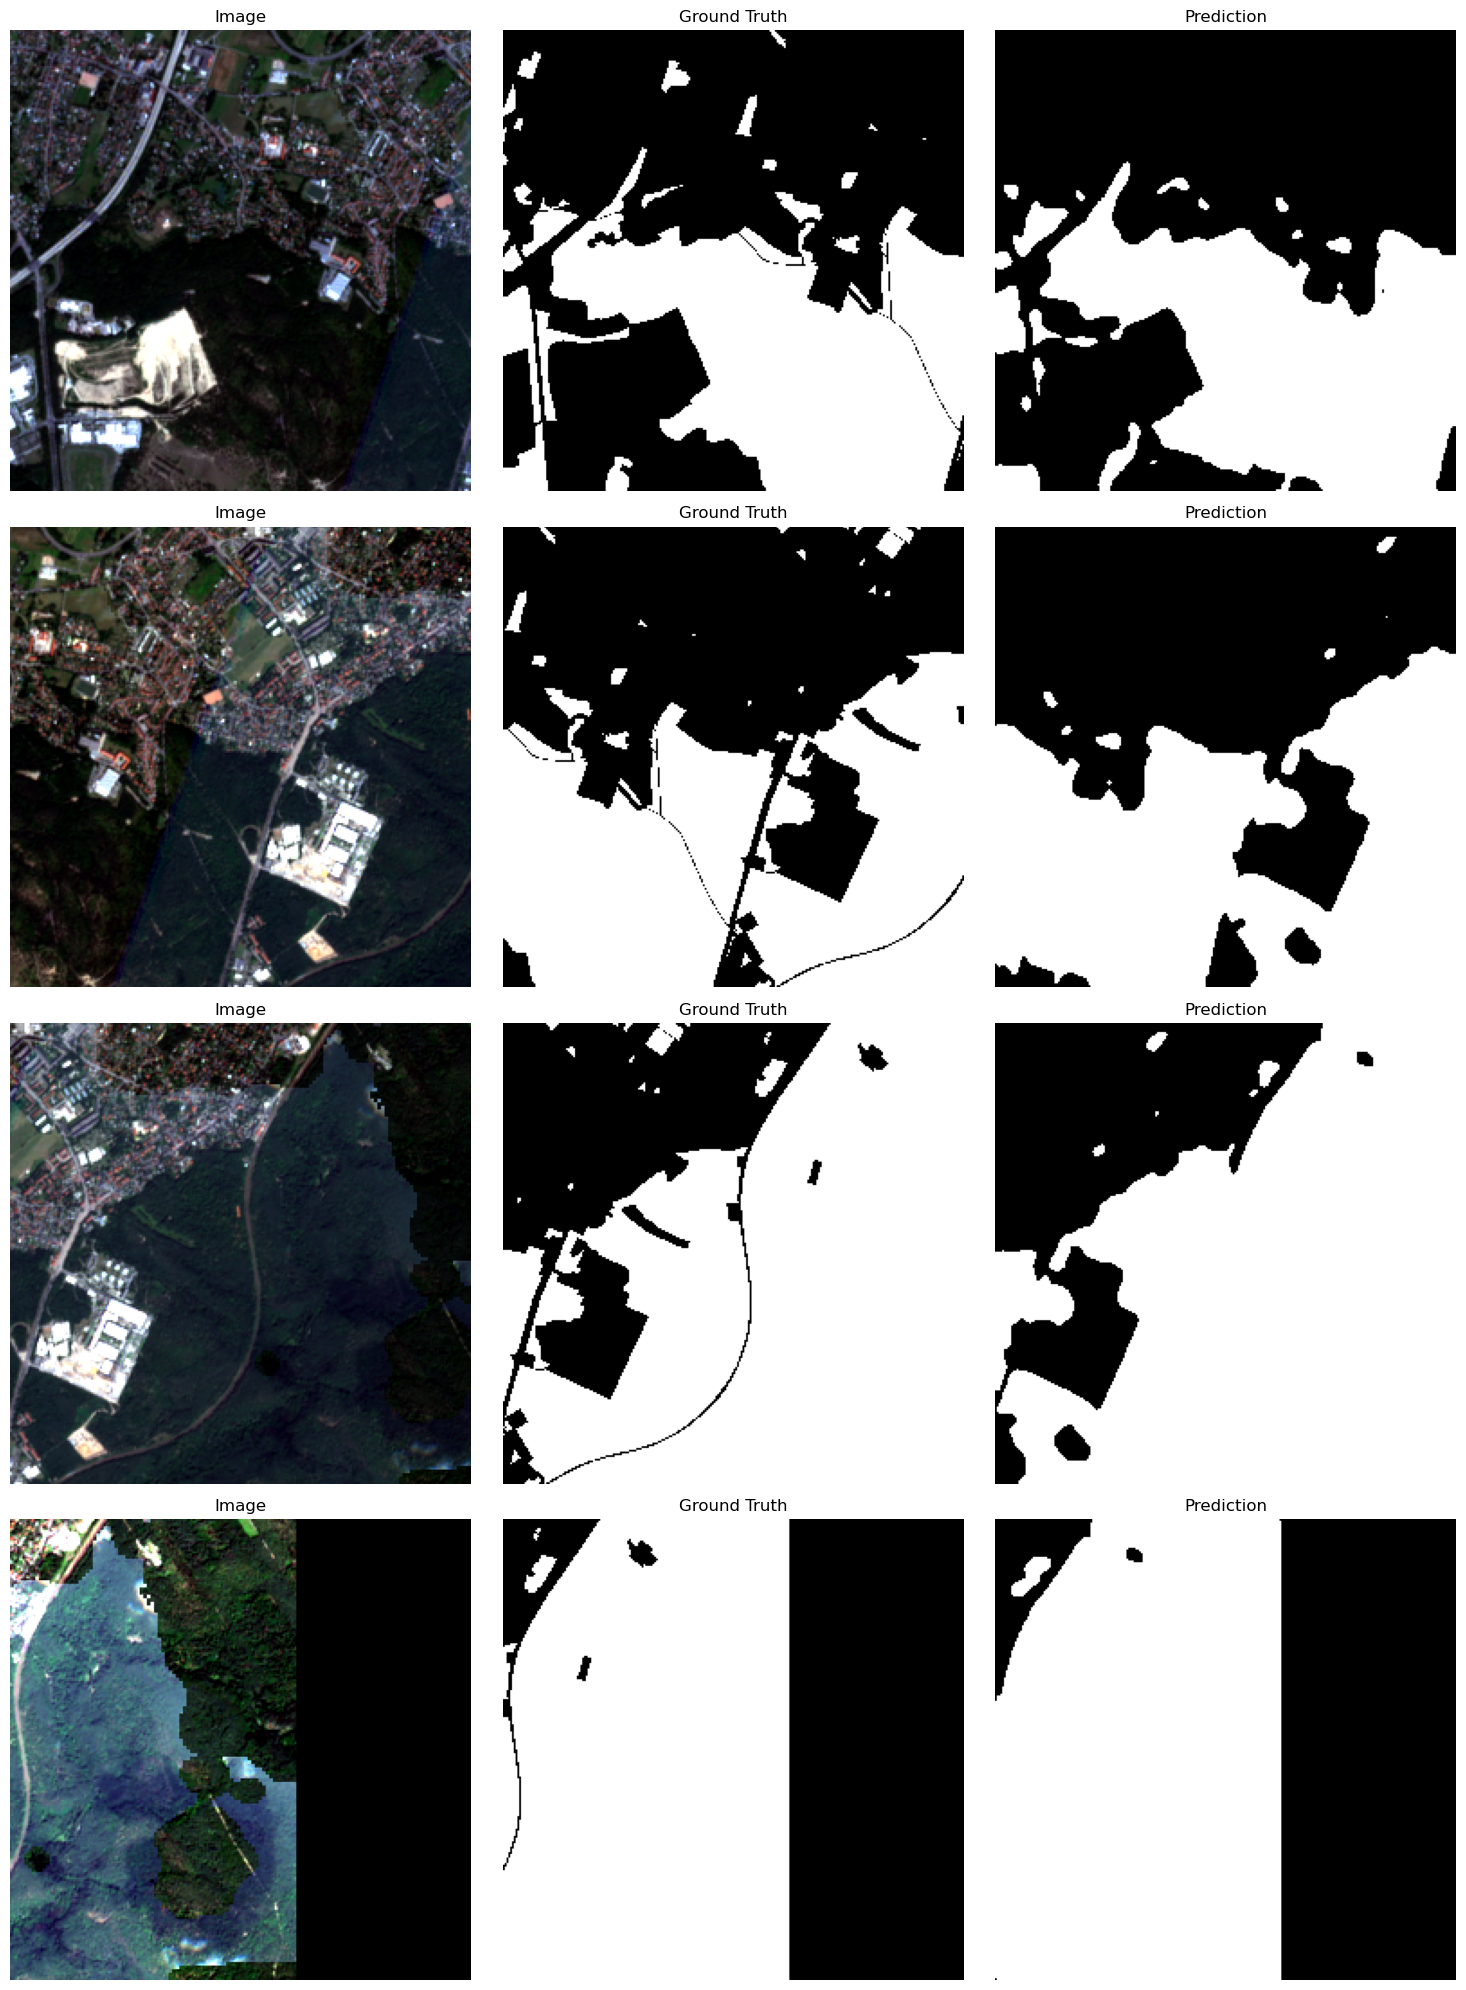

Prediction shape: torch.Size([8, 1, 256, 256])
Mask shape: torch.Size([8, 256, 256])
Sample 0 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9999426138400974
Sample 1 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9995395541191101
Sample 2 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 3 - Image shape: (13, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8388746380805969


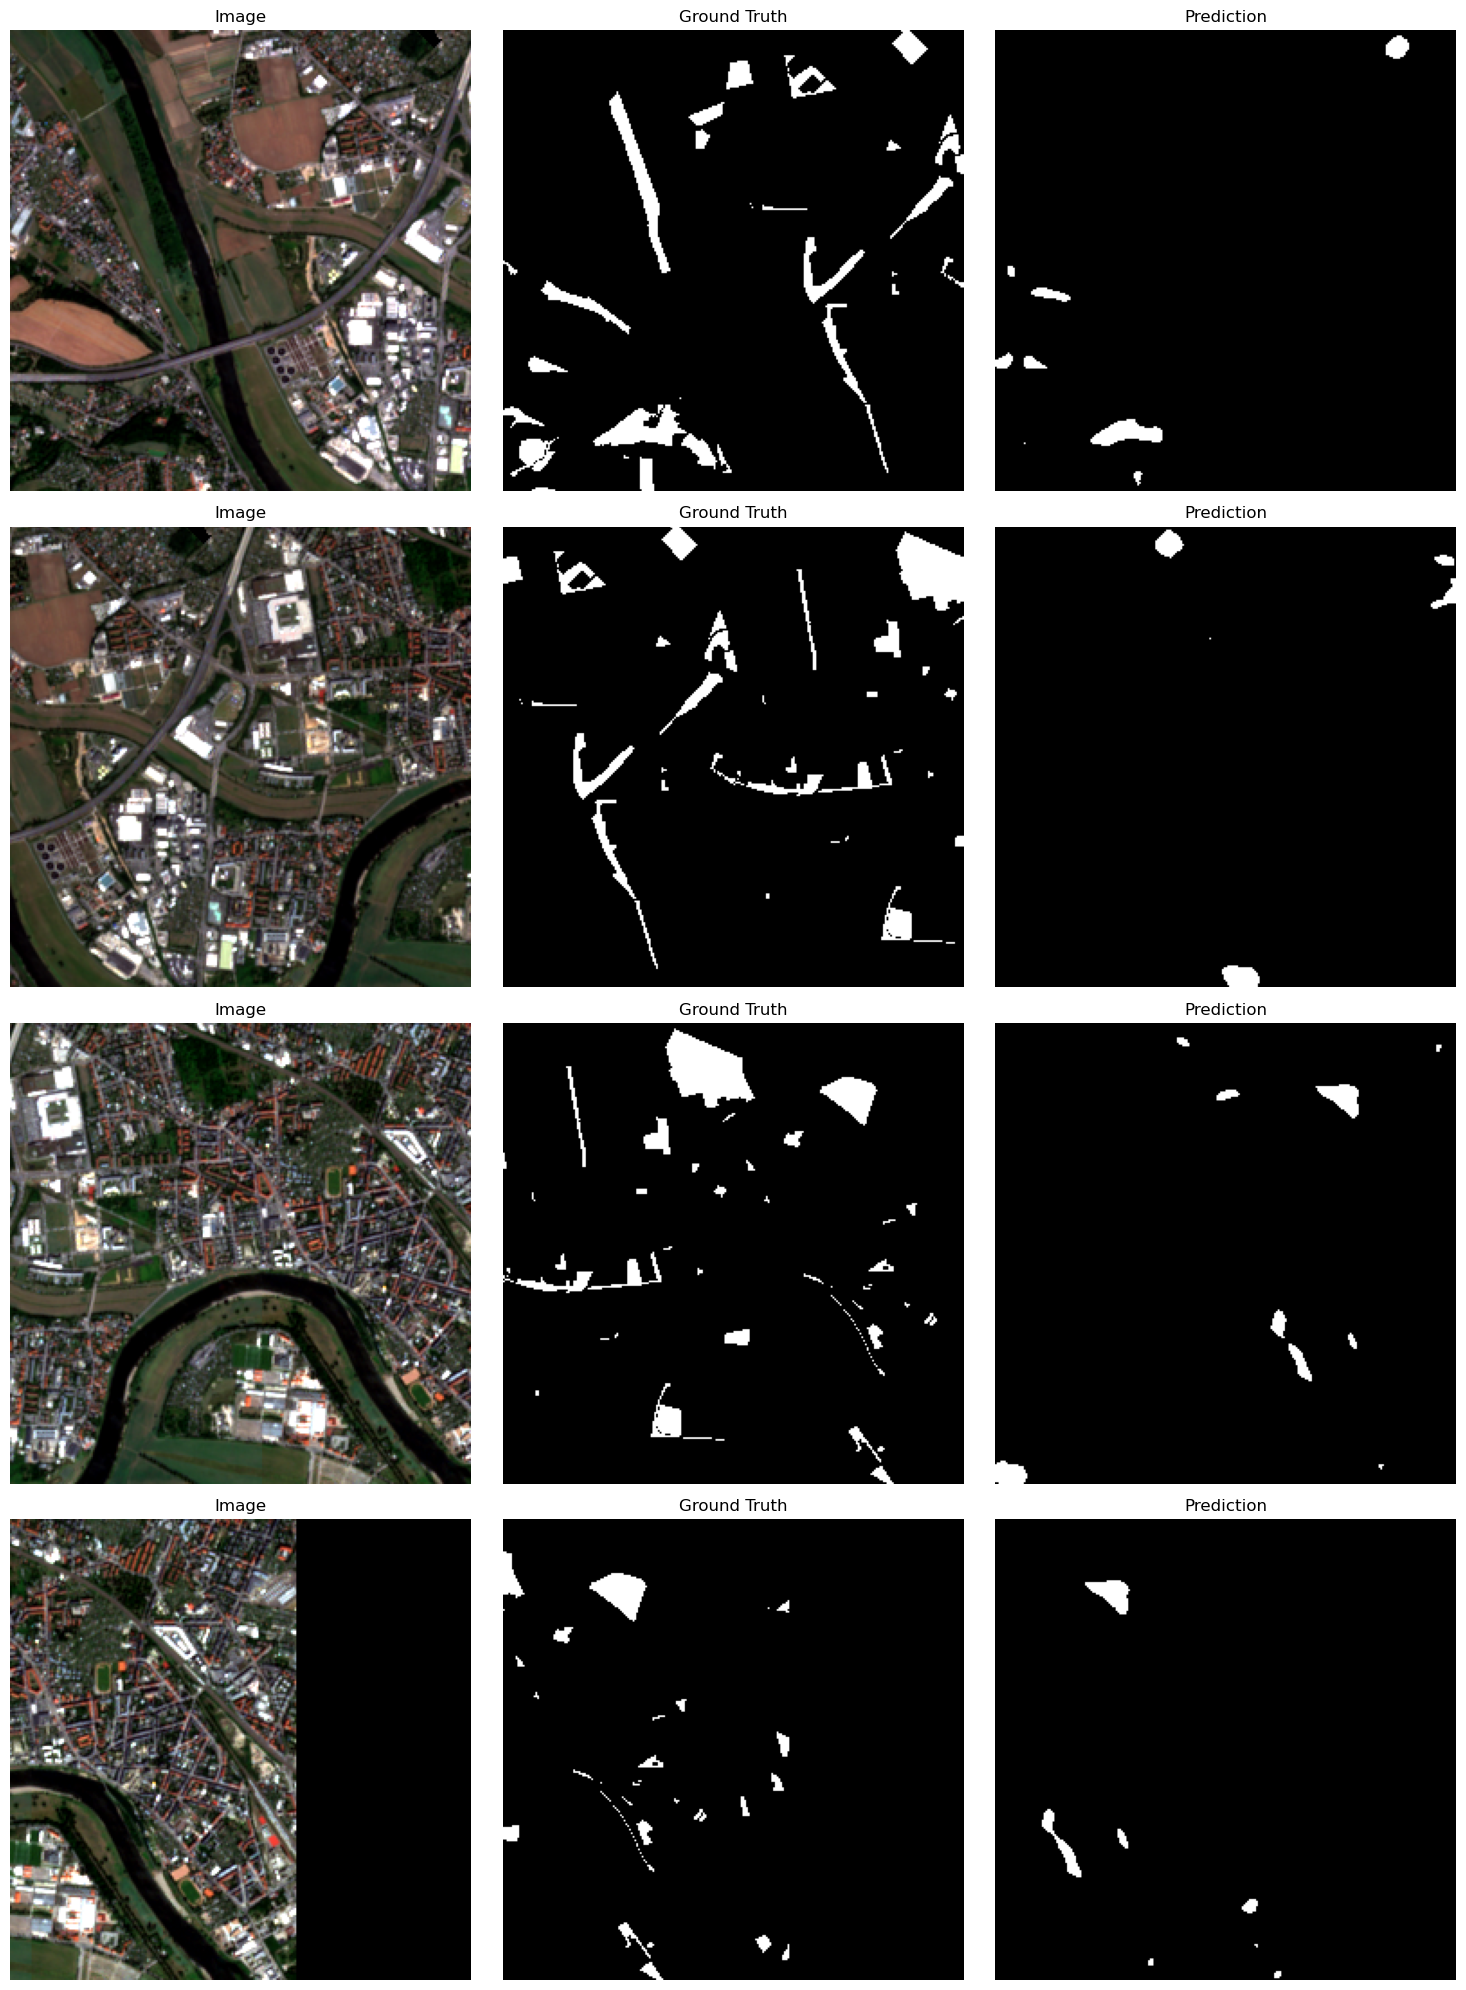

In [ ]:
# visualize_predictions_test(task, test_loader, mode='additional', replace_band_pos=[13])
visualize_predictions(task, test_loader, mode="original")

In [1]:
# visualize_predictions(task, test_loader, mode='additional', replace_band_pos=[13])
# visualize_predictions(task, test_loader, mode='original')